## Hierarchical Modeling of Protein Expression 

This tutorial presents how protein expression can be modeled using BioCRNpyler at various levels of abstraction. Various mixtures and mechanisms are used to express GFP and compare results across cells, extract, and PURE. The notebook explores whether default parameter values do something reasonable and how the models at different levels of detail with different mixtures and mechanisms compare.


In [1]:

import matplotlib.pyplot as plt
import numpy as np

import biocrnpyler as bcp
from biocrnpyler.utils.units import nM, uM, mM, sec, min, hrs


Start by creating a simple DNA assembly that expresses GFP. We will use this same assembly across all the different mixtures and mechanisms to compare results.


In [2]:
gfp_dna = bcp.DNAassembly(
    name='gfp', promoter='pconst', rbs='rbs_strong', protein='GFP'
)

Set initial simulation parameters.

In [3]:
initial_conditions_dict = {'dna_gfp': 1 * nM}
timepts = np.linspace(0, 6 * hrs, 1000)


### GFP expression in cell-free extract with one-step gene expression

In [4]:
expr_mixture = bcp.ExpressionExtract(
    name='expression',
    components=[gfp_dna],
)
expr_crn = expr_mixture.compile_crn()
expr_res = expr_crn.simulate_with_bioscrape_via_sbml(
    timepts, initial_condition_dict=initial_conditions_dict
)

### GFP expression in cell-free extract with simple gene expression mechanism

In [5]:
simple_mixture = bcp.SimpleTxTlExtract(
    name='simple',
    components=[gfp_dna],
)
simple_crn = simple_mixture.compile_crn()
simple_res = simple_crn.simulate_with_bioscrape_via_sbml(
    timepts, initial_condition_dict=initial_conditions_dict
)


### GFP expression in cell-free extract with gene expression machinery

In [6]:
regular_mixture = bcp.TxTlExtract(
    name='regular',
    components=[gfp_dna],
)
regular_crn = regular_mixture.compile_crn()
regular_res = regular_crn.simulate_with_bioscrape_via_sbml(
    timepts, initial_condition_dict=initial_conditions_dict
)

### GFP expression in cell-free extract with gene expression machinery and energy metabolism

In [7]:
energy_mixture = bcp.EnergyTxTlExtract(
    name='energy',
    components=[gfp_dna],
)
energy_crn = energy_mixture.compile_crn()
energy_res = energy_crn.simulate_with_bioscrape_via_sbml(
    timepts, initial_condition_dict=initial_conditions_dict
)


### Comparison of GFP expression across different modeling levels for cell-free mixture

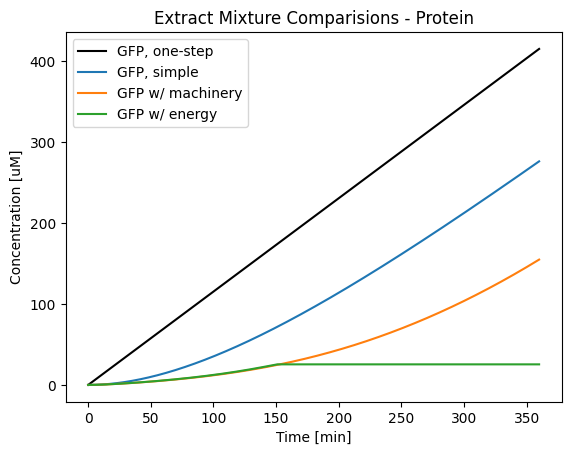

In [8]:
plt.figure(1)
plt.clf()

plt.plot(timepts / min, expr_res['protein_GFP'] / uM, 'k', label='GFP, one-step')
plt.plot(timepts / min, simple_res['protein_GFP'] / uM, label='GFP, simple')
plt.plot(timepts / min, regular_res['protein_GFP'] / uM, label='GFP w/ machinery')
plt.plot(timepts / min, energy_res['protein_GFP'] / uM, label='GFP w/ energy')

plt.title("Extract Mixture Comparisions - Protein")
plt.xlabel("Time [min]")
plt.ylabel("Concentration [uM]")
plt.legend()


### Comparison of mRNA expression across different modeling levels for cell-free mixture

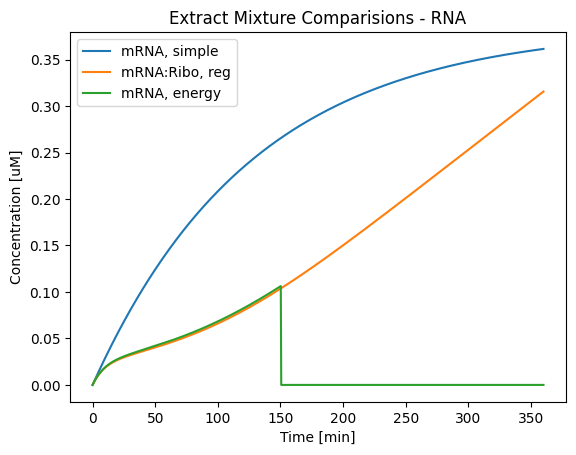

In [9]:
plt.figure(2)
plt.clf()

plt.plot(timepts / min, simple_res['rna_gfp'] / uM, label='mRNA, simple')
plt.plot(
    timepts / min,
    regular_res['complex_protein_Ribo_rna_gfp_'],
    label='mRNA:Ribo, reg',
)
plt.plot(
    timepts / min,
    energy_res[
        'complex_metabolite_ATP_4x_metabolite_amino_acids_protein_Ribo_rna_gfp_'
    ] / uM,
    label='mRNA, energy',
)

plt.title("Extract Mixture Comparisions - RNA")
plt.xlabel("Time [min]")
plt.ylabel("Concentration [uM]")
plt.legend()


### Analysis of energy-based mixtures

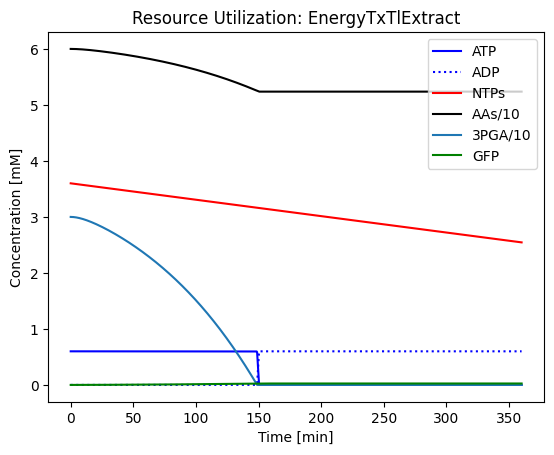

In [10]:
plt.figure(3)
plt.clf()

plt.plot(timepts / min, energy_res['metabolite_ATP'] / mM, 'b-', label='ATP')
plt.plot(timepts / min, energy_res['metabolite_ADP'] / mM, 'b:', label='ADP')
plt.plot(timepts / min, energy_res['metabolite_NTPs'] / mM, 'r', label='NTPs')
plt.plot(
    timepts / min,
    energy_res['metabolite_amino_acids'] / mM / 10,
    'k',
    label='AAs/10',
)
plt.plot(
    timepts / min,
    energy_res['metabolite_Fuel_3PGA'] / mM / 10,
    label='3PGA/10',
)
# plt.plot(timepts/min, energy_res['metabolite_Fuel_3PGA']/mM, label='3PGA')
plt.plot(timepts / min, energy_res['protein_GFP'] / mM, 'g', label='GFP')

plt.title("Resource Utilization: EnergyTxTlExtract")
plt.xlabel("Time [min]")
plt.ylabel("Concentration [mM]")
plt.legend()


### Comparison of extract-based mixtures with expression of two proteins: GFP and CFP

For CFP, we repeat the steps above and then re-create the CRNs with both GFP and CFP in the mixture.

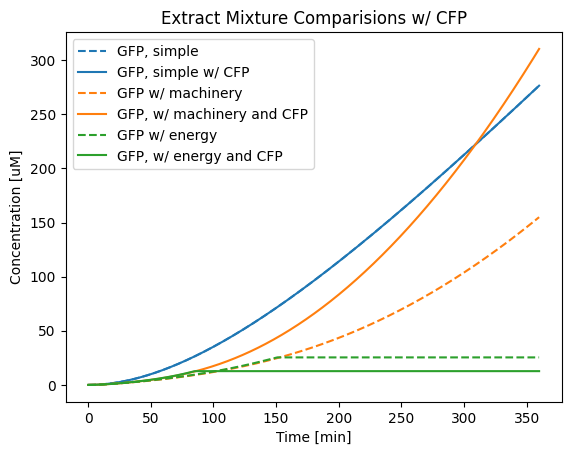

In [11]:
plt.figure(4)
plt.clf()

cfp_initial_conditions = initial_conditions_dict.copy()
cfp_initial_conditions['dna_cfp'] = 1 * nM

# Add some additional DNA that will utilize resources
cfp_dna = bcp.DNAassembly(
    name='cfp', promoter='pconst', rbs='rbs_strong', protein='CFP'
)

# Simple mixture should not be affected
cfp_simple_mixture = bcp.SimpleTxTlExtract(
    name='energy',
    components=[gfp_dna, cfp_dna],
    parameter_file=[
        'mixtures/extract_parameters.tsv',
    ],
)
cfp_simple_crn = cfp_simple_mixture.compile_crn()
cfp_simple_res = cfp_simple_crn.simulate_with_bioscrape_via_sbml(
    timepts, initial_condition_dict=cfp_initial_conditions
)

# Regular mixture should have lower expression, but not limits
cfp_regular_mixture = bcp.TxTlExtract(
    name='energy',
    components=[gfp_dna, cfp_dna],
    parameter_file=[
        'mixtures/extract_parameters.tsv',
    ],
)
cfp_regular_crn = cfp_regular_mixture.compile_crn()
cfp_regular_res = cfp_regular_crn.simulate_with_bioscrape_via_sbml(
    timepts, initial_condition_dict=cfp_initial_conditions
)

# Energy mixture should have lower expression, earlier saturation
cfp_energy_mixture = bcp.EnergyTxTlExtract(
    name='energy',
    components=[gfp_dna, cfp_dna],
    parameter_file=[
        'mixtures/extract_parameters.tsv',
    ],
)
cfp_energy_crn = cfp_energy_mixture.compile_crn()
cfp_energy_res = cfp_energy_crn.simulate_with_bioscrape_via_sbml(
    timepts, initial_condition_dict=cfp_initial_conditions
)

lines = plt.plot(
    timepts / min, simple_res['protein_GFP'] / uM, '--', label='GFP, simple'
)
plt.plot(
    timepts / min,
    cfp_simple_res['protein_GFP'] / uM,
    color=lines[0].get_color(),
    label='GFP, simple w/ CFP',
)

lines = plt.plot(
    timepts / min, regular_res['protein_GFP'] / uM, '--', label='GFP w/ machinery'
)
plt.plot(
    timepts / min,
    cfp_regular_res['protein_GFP'] / uM,
    color=lines[0].get_color(),
    label='GFP, w/ machinery and CFP',
)

lines = plt.plot(
    timepts / min, energy_res['protein_GFP'] / uM, '--', label='GFP w/ energy'
)
plt.plot(
    timepts / min,
    cfp_energy_res['protein_GFP'] / uM,
    color=lines[0].get_color(),
    label='GFP, w/ energy and CFP',
)

plt.title("Extract Mixture Comparisions w/ CFP")
plt.xlabel("Time [min]")
plt.ylabel("Concentration [uM]")
plt.legend()



### Modeling of GFP expression in PURE cell-free protein expression system

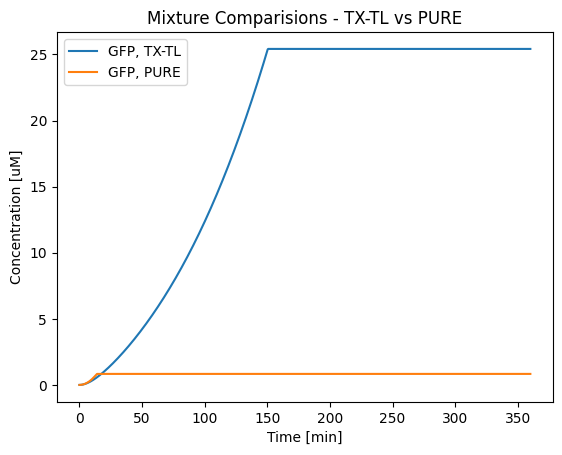

In [12]:

pure_mixture = bcp.BasicPURE(
    name='regular',
    components=[gfp_dna],
)
pure_crn = pure_mixture.compile_crn()
pure_res = pure_crn.simulate_with_bioscrape_via_sbml(
    timepts, initial_condition_dict=initial_conditions_dict
)

plt.figure(5)
plt.clf()
plt.plot(timepts / min, energy_res['protein_GFP'] / uM, label='GFP, TX-TL')
plt.plot(timepts / min, pure_res['protein_GFP'] / uM, label='GFP, PURE')

plt.title("Mixture Comparisions - TX-TL vs PURE")
plt.xlabel("Time [min]")
plt.ylabel("Concentration [uM]")
plt.legend()


### Analysis of protein expression in PURE mixture 

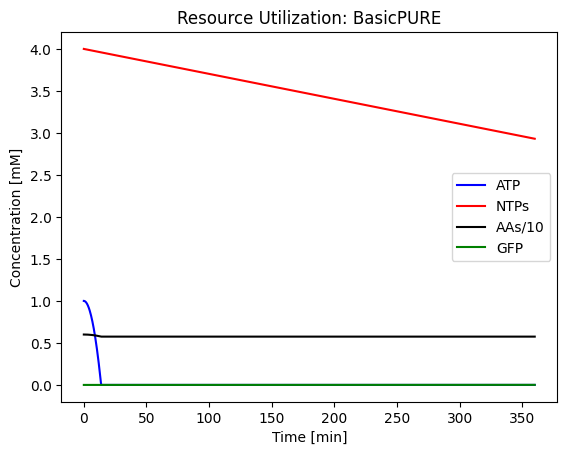

In [13]:
plt.figure(6)
plt.clf()

plt.plot(timepts / min, pure_res['metabolite_ATP'] / mM, 'b-', label='ATP')
plt.plot(timepts / min, pure_res['metabolite_NTPs'] / mM, 'r', label='NTPs')
plt.plot(
    timepts / min,
    pure_res['metabolite_AAs'] / mM / 10,
    'k',
    label='AAs/10',
)
plt.plot(timepts / min, pure_res['protein_GFP'] / mM, 'g', label='GFP')

plt.title("Resource Utilization: BasicPURE")
plt.xlabel("Time [min]")
plt.ylabel("Concentration [mM]")
plt.legend()


### Modeling of GFP expression in cell-based mixture
We model the GFP DNA assembly in cell-based mixtures with varying levels of detail: the expression dilution mixture that uses one step gene expression and basic catalysis, the simple TxTl dilution mixture that includes intermediate mRNA with other mass-action kinetics without explicit resource modeling, and the TxTl dilution mixture that includes intermediate mRNA and the resources (RNAP, RNAse, ribosomes) explicitly.  

In [32]:
cell_mech_parameters = {
    'kb': 100,
    'ku': 10,
    'ktx': 0.05,
    'ktl': 0.05,
}

cell_initial_conditions_dict = {'dna_gfp': 1 * nM}

cell_expr_mixture = bcp.ExpressionDilutionMixture(
    name='cell_expression',
    components=[gfp_dna],
    parameters=cell_mech_parameters,
    overwrite_parameters=True,
)
cell_expr_crn = cell_expr_mixture.compile_crn()
cell_expr_res = cell_expr_crn.simulate_with_bioscrape_via_sbml(
    timepts, initial_condition_dict=cell_initial_conditions_dict
)

cell_simple_mixture = bcp.SimpleTxTlDilutionMixture(
    name='cell_simple_txtl',
    components=[gfp_dna],
    parameters=cell_mech_parameters,
    overwrite_parameters=True,
)
cell_simple_crn = cell_simple_mixture.compile_crn()
cell_simple_res = cell_simple_crn.simulate_with_bioscrape_via_sbml(
    timepts, initial_condition_dict=cell_initial_conditions_dict
)

cell_regular_parameters = {
    **cell_mech_parameters,
    ('dilution', None, 'kdil'): 1e-4,
}

cell_regular_mixture = bcp.TxTlDilutionMixture(
    name='cell_with_machinery',
    components=[gfp_dna],
    parameters=cell_regular_parameters,
    overwrite_parameters=True,
)
cell_regular_crn = cell_regular_mixture.compile_crn()
cell_regular_initial_conditions_dict = {
    'dna_gfp': 1 * nM,
    cell_regular_mixture.rnap.get_species(): 15 * uM,
    cell_regular_mixture.ribosome.get_species(): 150 * uM,
    cell_regular_mixture.rnase.get_species(): 45 * uM,
    'dna_cellular_processes': 2 * uM,
}
cell_regular_res = cell_regular_crn.simulate_with_bioscrape_via_sbml(
    timepts, initial_condition_dict=cell_regular_initial_conditions_dict
)


### Analysis of protein expression in cell-based mixture

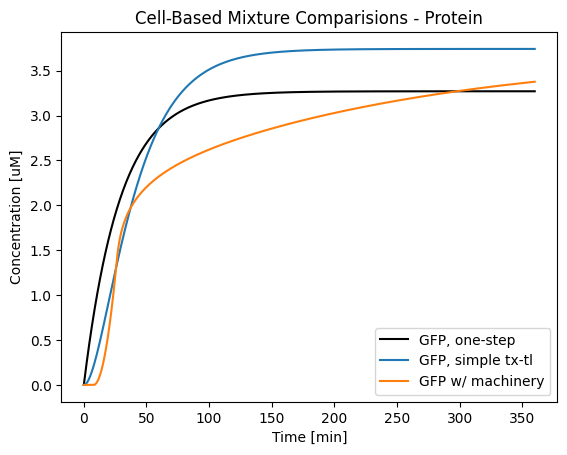

In [33]:
plt.figure(7)
plt.clf()

plt.plot(
    timepts / min,
    cell_expr_res['protein_GFP'] / uM,
    'k',
    label='GFP, one-step',
)
plt.plot(
    timepts / min,
    cell_simple_res['protein_GFP'] / uM,
    label='GFP, simple tx-tl',
)
plt.plot(
    timepts / min,
    cell_regular_res['protein_GFP'] / uM,
    label='GFP w/ machinery',
)

plt.title("Cell-Based Mixture Comparisions - Protein")
plt.xlabel("Time [min]")
plt.ylabel("Concentration [uM]")
plt.legend()


In [34]:
# end